# 문제 4 — 연립방정식과 해의 판정 (가우스 소거·rank·행렬식·역행렬)

풀어야 하는 연립방정식은 다음과 같습니다. 해는 정수로 떨어집니다.

$$\begin{aligned}
3x_1 + x_2 + 2x_3 &= 11\\
x_1 + 4x_2 + x_3 &= 1\\
2x_1 - x_2 + 5x_3 &= 20
\end{aligned}$$

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 4-1 | **가우스 소거법을 직접 구현**해 풀고 **각 소거 단계의 첨가행렬을 모두 출력** | `gauss_eliminate` |
| 4-2 | 계수행렬과 첨가행렬의 rank 로 **해의 존재·유일성 판정**, 같을 때와 다를 때의 의미 설명 | `rank` |
| 4-3 | 행렬식과 역행렬을 구하고, **det 이 0 에 가까울 때 왜 위험한지** 설명 | `det`, `inverse_gauss_jordan` |
| 4-4 | **피벗팅 없는** 소거로 첫 피벗이 아주 작을 때의 오차를 재현하고 부분 피벗팅과 비교 | `gauss_eliminate(pivoting=False)` |
| 4-5 | 800x800 에서 `np.linalg.solve` vs `역행렬을 구해서 곱하기` 의 **시간·잔차** 비교 | — |

> `# --- 검증 ---` 셀과 그래프 셀은 제공된 코드입니다. 참조하는 변수 이름을 맞춰 주세요.

In [19]:
import os

# 벤치마크 공정성을 위해 numpy import 전에 BLAS 스레드 수를 1 로 고정한다.
# 수백 x 수백 크기에서는 실제 연산보다 스레드 풀 생성/동기화 오버헤드가 더 커서
# 알고리즘 차이가 통째로 가려질 수 있다.
for _var in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "OMP_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_var] = "1"

import inspect
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.vectors import det, gauss_eliminate, inverse_gauss_jordan, rank, row_echelon

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


# 풀어야 하는 연립방정식
A = np.array([[3.0, 1.0, 2.0],
              [1.0, 4.0, 1.0],
              [2.0, -1.0, 5.0]])
b = np.array([11.0, 1.0, 20.0])
print("A =\n", A, "\n\nb =", b)

A =
 [[ 3.  1.  2.]
 [ 1.  4.  1.]
 [ 2. -1.  5.]] 

b = [11.  1. 20.]


## 4-1. 가우스 소거법 — 단계별 첨가행렬

가우스 소거는 **첨가행렬 $[A|b]$ 에 행 연산만 적용**해 상삼각으로 만든 뒤
뒤에서부터 대입해 푸는 방법입니다. 행 연산은 해집합을 바꾸지 않습니다.

부분 피벗팅(partial pivoting)은 각 열에서 **절댓값이 가장 큰 성분을 피벗으로**
올리는 행 교환입니다. 왜 그렇게 하는지는 4-4 에서 직접 확인합니다.

**할 일**

- `src/vectors.py` 의 `gauss_eliminate` 를 구현하세요.
  `verbose=True` 면 **초기 첨가행렬과 각 단계(행 교환 / 소거)의 첨가행렬을 모두 출력**해야 합니다.
  반환값 `steps` 에는 단계별 첨가행렬(초기 포함)을 순서대로 담습니다.
- 구현한 소스를 `inspect.getsource` 로 노트북에 출력해 두세요.
- 해를 구하고 `A @ x` 가 `b` 와 같은지, 정수로 떨어지는지 확인하세요.
  **코드를 돌리기 전에 손으로 먼저 풀어 보고** 정수해를 예상해 두세요.

In [20]:
print(inspect.getsource(gauss_eliminate))

def gauss_eliminate(A, b, pivoting: bool = True, verbose: bool = False):
    """가우스 소거법 + 후진대입으로 Ax = b 를 푼다.

    Parameters
    ----------
    pivoting : True 면 부분 피벗팅을 적용한다. False 면 피벗을 그대로 쓴다
               (문제 4-4 에서 두 경우의 오차를 비교하므로 **둘 다 동작해야 한다**).
    verbose  : True 면 각 소거 단계의 첨가행렬 [A|b] 를 출력한다
               (문제 4-1 이 요구하는 '단계별 출력').

    Returns
    -------
    x : 해 벡터
    steps : 단계별 첨가행렬 [A|b] 스냅샷 리스트 (초기 상태 포함)

    피벗이 0 이면 해가 유일하지 않다 -> ZeroDivisionError.
    """
    # TODO: 문제 4-1
    A_mat = np.array(A, dtype=float)
    b_vec = np.array(b, dtype=float).reshape(-1, 1)
    m, n = A_mat.shape
    
    if m != n:
        raise ValueError("정사각 행렬 구조의 시스템만 가우스 소거를 지원합니다.")
        
    # [A|b] 첨가 행렬 생성
    Aug = np.hstack([A_mat, b_vec])
    steps = [Aug.copy()]
    
    if verbose:
        print("초기 첨가 행렬 상태:")
        print(Aug)
        
    n_swaps = 0
    # 1. 전진 소거 단계 (Forward Elimination)
    for r in range(n):
        tol = 1e-25
        
        if pivoting:
      

In [21]:
# TODO: x, steps = gauss_eliminate(A, b, pivoting=True, verbose=True)
x, steps = gauss_eliminate(A, b, pivoting=True, verbose=True)

초기 첨가 행렬 상태:
[[ 3.  1.  2. 11.]
 [ 1.  4.  1.  1.]
 [ 2. -1.  5. 20.]]
-> 0열 아래 성분 소거 완료:
[[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.       -1.666667  3.666667 12.666667]]
-> 1열 아래 성분 소거 완료:
[[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.        0.        3.818182 11.454545]]


In [22]:
# TODO: 최종 해 x, 정수해 여부, A @ x, 잔차 |A x - b| 를 출력하세요.
# TODO: np.linalg.solve(A, b) (# 비교 대상) 와도 비교하세요.
print(f"1. 가우스 소거법 최종 해 (x)      : {x}")
is_integer = np.all(np.isclose(x, np.round(x), atol=1e-9))
print(f"2. 해가 정수로 떨어지는가?          : {is_integer} (예상 정수해: {np.round(x).astype(int)})")

Ax = A @ x
residual = np.linalg.norm(Ax - b) # [검산] 넘파이 내장 norm 함수로 잔차 크기 측정
print(f"3. A @ x 결과                     : {Ax}")
print(f"4. 잔차 크기 |A x - b|            : {residual:.6e}")

x_linalg = np.linalg.solve(A, b) # (# 비교 대상)
is_same_with_linalg = np.allclose(x, x_linalg, atol=1e-12)
print(f"5. np.linalg.solve(A, b) 결과     : {x_linalg}")
print(f"6. 내 구현과 내장 함수 해의 일치 여부: {is_same_with_linalg}")

1. 가우스 소거법 최종 해 (x)      : [ 2. -1.  3.]
2. 해가 정수로 떨어지는가?          : True (예상 정수해: [ 2 -1  3])
3. A @ x 결과                     : [11.  1. 20.]
4. 잔차 크기 |A x - b|            : 3.580362e-15
5. np.linalg.solve(A, b) 결과     : [ 2. -1.  3.]
6. 내 구현과 내장 함수 해의 일치 여부: True


In [23]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("해가 (2, -1, 3)", np.allclose(x, [2.0, -1.0, 3.0]))
ok &= check("해가 정수로 떨어진다", np.allclose(x, np.round(x)))
ok &= check("A @ x == b", np.allclose(A @ x, b))
ok &= check("np.linalg.solve 와 일치", np.allclose(x, np.linalg.solve(A, b)))      # 비교 대상
ok &= check("소거 단계가 모두 기록되었다 (단계 수 {} >= 3)".format(len(steps)), len(steps) >= 3)
ok &= check("첫 기록이 초기 첨가행렬 [A|b]", np.allclose(steps[0], np.hstack([A, b.reshape(-1, 1)])))
ok &= check("마지막 첨가행렬이 상삼각", np.allclose(np.tril(steps[-1][:, :3], -1), 0.0))
ok &= check("상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)",
            np.isclose(abs(np.prod(np.diag(steps[-1][:, :3]))), abs(det(A))))
print("\n4-1 전체 통과:", ok)

[PASS] 해가 (2, -1, 3)
[PASS] 해가 정수로 떨어진다
[PASS] A @ x == b
[PASS] np.linalg.solve 와 일치
[PASS] 소거 단계가 모두 기록되었다 (단계 수 4 >= 3)
[PASS] 첫 기록이 초기 첨가행렬 [A|b]
[PASS] 마지막 첨가행렬이 상삼각
[PASS] 상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)

4-1 전체 통과: True


## 4-2. rank 로 해의 존재·유일성 판정

미지수가 $n$ 개일 때, **루셰-카펠리 정리**로 다음처럼 판정합니다.

| 조건 | 판정 |
|---|---|
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) = n$ | 유일해 |
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) < n$ | 해가 무한히 많음 (자유변수 $n - \mathrm{rank}$ 개) |
| $\mathrm{rank}(A) < \mathrm{rank}([A\,|\,b])$ | 해 없음 |

**할 일**

- 이 문제의 두 rank 를 `rA`, `rAb` 에 구해 판정하세요.
- 두 rank 가 같다는 것이 $b$ 와 $A$ 의 열공간 사이에서 무엇을 뜻하는지,
  다르면 소거 결과에 어떤 행이 나타나는지 **직접 예를 만들어** 확인하세요.
  아래 `A_dep` (2행이 1행의 배수) 에 모순되는 `b_bad` 와 모순 없는 `b_ok` 를 각각 넣어 봅니다.

### 두 rank 가 같을 때와 다를 때의 의미

- 같을 때: `벡터 b가 행렬 A의 열공간에 존재, A의 열벡터들의 선형 결합으로 b를 만들어낼 수 있으므로 최소한 하나 이상의 해가 존재`
- 다를 때: `벡터 b가 행렬 A의 열공간 밖에 존재, 해는 존재하지 않음`
- 같지만 n 보다 작을 때: `변수의 개수보다 독립적인 방정식의 수가 부족하여 고정되지 않는 자유변수가 n - rank 개 발생, 해가 무한히 많음`

In [24]:
Ab = np.hstack([A, b.reshape(-1, 1)])

A_dep = np.array([[1.0, 2.0, 3.0],
                  [3.0, 6.0, 9.0],      # 1행의 3배
                  [1.0, 1.0, 1.0]])

# TODO: rA = rank(A), rAb = rank(Ab), n_unknowns = A.shape[1] 을 출력하고 판정 결과를 출력하세요.
#       np.linalg.matrix_rank (# 검산용) 와도 비교하세요.
rA = rank(A)
rAb = rank(Ab)
n_unknowns = A.shape[1]

print(f"계수행렬 rank(A)        : {rA}  (검산 matrix_rank: {np.linalg.matrix_rank(A)})")
print(f"첨가행렬 rank([A|b])    : {rAb}  (검산 matrix_rank: {np.linalg.matrix_rank(Ab)})")
print(f"미지수의 개수 (n)       : {n_unknowns}")

# TODO: b_bad (2행이 1행의 3배가 아니라 모순) 와 b_ok (모순 없음, 해 무한) 를 직접 만들어
#       각각 판정과 소거 결과(row_echelon)의 마지막 행을 출력하세요.
b_bad = np.array([5.0, 20.0, 2.0]) 
Ab_bad = np.hstack([A_dep, b_bad.reshape(-1, 1)])
U_bad, _, _ = row_echelon(Ab_bad, pivoting=True)

b_ok = np.array([5.0, 15.0, 2.0]) 
Ab_ok = np.hstack([A_dep, b_ok.reshape(-1, 1)])
U_ok, _, _ = row_echelon(Ab_ok, pivoting=True)

print("\n[실험 1] b_bad (모순 발생 - 해 없음)")
print(f"-> rank(A_dep)={rank(A_dep)}, rank(Ab_bad)={rank(Ab_bad)}")
print(f"-> row_echelon 변환 후 마지막 행 성분: {U_bad[-1, :]}")
print("   (해설: 좌변은 [0, 0, 0]인데 우변에 0이 아닌 상수가 남아 해가 없음이 증명)")

print("\n[실험 2] b_ok (모순 없음 - 해 무한)")
print(f"-> rank(A_dep)={rank(A_dep)}, rank(Ab_ok)={rank(Ab_ok)}")
print(f"-> row_echelon 변환 후 마지막 행 성분: {U_ok[-1, :]}")
print("   (해설: 마지막 행 전체가 [0, 0, 0, 0]으로 소거되어 자유변수가 존재함이 증명)")

계수행렬 rank(A)        : 3  (검산 matrix_rank: 3)
첨가행렬 rank([A|b])    : 3  (검산 matrix_rank: 3)
미지수의 개수 (n)       : 3

[실험 1] b_bad (모순 발생 - 해 없음)
-> rank(A_dep)=2, rank(Ab_bad)=3
-> row_echelon 변환 후 마지막 행 성분: [ 0.        0.        0.       -1.666667]
   (해설: 좌변은 [0, 0, 0]인데 우변에 0이 아닌 상수가 남아 해가 없음이 증명)

[실험 2] b_ok (모순 없음 - 해 무한)
-> rank(A_dep)=2, rank(Ab_ok)=2
-> row_echelon 변환 후 마지막 행 성분: [0. 0. 0. 0.]
   (해설: 마지막 행 전체가 [0, 0, 0, 0]으로 소거되어 자유변수가 존재함이 증명)


In [25]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("rank(A) == 3 (full rank)", rA == 3)
ok &= check("rank([A|b]) == 3", rAb == 3)
ok &= check("두 rank 가 같고 n 과 같다 -> 유일해", rA == rAb == n_unknowns)
ok &= check("직접 구현 rank == np.linalg.matrix_rank",                                   # 검산용
            rA == np.linalg.matrix_rank(A) and rAb == np.linalg.matrix_rank(Ab))
ok &= check("A_dep 의 rank 는 2", rank(A_dep) == 2)
ok &= check("모순 케이스는 rank(A) < rank([A|b])",
            rank(A_dep) < rank(np.hstack([A_dep, np.asarray(b_bad, float).reshape(-1, 1)])))
ok &= check("무모순 종속 케이스는 두 rank 가 같고 n 보다 작다",
            rank(A_dep) == rank(np.hstack([A_dep, np.asarray(b_ok, float).reshape(-1, 1)])) < 3)
print("\n4-2 전체 통과:", ok)

[PASS] rank(A) == 3 (full rank)
[PASS] rank([A|b]) == 3
[PASS] 두 rank 가 같고 n 과 같다 -> 유일해
[PASS] 직접 구현 rank == np.linalg.matrix_rank
[PASS] A_dep 의 rank 는 2
[PASS] 모순 케이스는 rank(A) < rank([A|b])
[PASS] 무모순 종속 케이스는 두 rank 가 같고 n 보다 작다

4-2 전체 통과: True


## 4-3. 행렬식과 역행렬 — 그리고 $\det \approx 0$ 의 위험

행렬식은 행 사다리꼴의 **대각성분 곱 x (-1)^(행 교환 횟수)** 로 구합니다.
역행렬은 가우스-조던 소거 $[A|I] \rightarrow [I|A^{-1}]$ 로 구합니다.

**왜 $\det \approx 0$ 일 때 역행렬이 위험한지** 두 관점에서 설명해 보세요.

- 여인수 공식 $A^{-1} = \frac{1}{\det A}\mathrm{adj}(A)$ 에서 무슨 일이 생기는가
- 소거 관점에서 작은 피벗으로 나눈다는 것은 무엇을 뜻하는가

그리고 한 가지 더 확인해 보세요. $\det(cA)=c^n\det(A)$ 이므로
행렬 전체에 0.01 을 곱하기만 해도 $\det$ 는 크게 작아집니다.
그때 **해의 정확도도 같이 나빠지는지** 실험으로 확인하고,
그렇지 않다면 실무에서는 무엇을 기준으로 삼아야 하는지 조사해 적으세요.
(힌트: `np.linalg.cond`)

### det ≈ 0 이 위험한 이유와 진짜 판정 기준

- 여인수 공식 관점: `detA가 0에 매우 가까워지면 역행렬을 구할 때 adj(A)를 매우 작은 값으로 나누는 과정에서 역행렬의 원소들이 급격히 커지며 미세한 오차가 결과에 거대하게 증폭되는 수치적 불안정성이 발생`
- 소거 관점: `컴퓨터는 실수를 유한한 비트로 표현하므로 소거 과정에서 0에 가까운 아주 작은 피벗으로 행 전체를 나누면 부동소수점 반올림 오차가 무지막지하게 커짐`
- 스케일 실험에서 관찰한 것: `전체 행렬에 작은 c를 곱하면 행렬식은 c^n배만큼 급격하게 작아져 0에 근접하지만, 실제 방정식의 본질적인 성질이나 컴퓨터가 느끼는 해의 정확도 및 조건수는 전혀 나빠지지 않고 일정하게 유지되어, det ≈ 0이 반드시 수치적 위험을 의미하지는 않음`
- 실무 판정 기준과 그 의미: `행렬식 대신 조건수를 기준으로, 입력의 미세한 변화가 출력에 최대 몇 배의 오차로 증폭될 수 있는지를 나타내는 지표, 1에 가까우면 우수한 조건, 크면 특이행렬에 가까운 위험한 상태로 판정`

In [26]:
# TODO: detA = det(A), invA = inverse_gauss_jordan(A) 를 구해 출력하고,
#       np.linalg.det / np.linalg.inv (# 검산용) 와 비교하세요.
detA = det(A)
invA = inverse_gauss_jordan(A)

print(f"구현한 det(A)       : {detA:.6f} (검산 linalg.det: {np.linalg.det(A):.6f})")
print(f"구현한 역행렬 inv(A) :\n{invA}")
print(f"검산용 linalg.inv(A):\n{np.linalg.inv(A)}")
# TODO: A @ invA == I 인지, invA @ b 가 4-1 의 해와 같은지 확인하세요.
I_check = A @ invA
x_check = invA @ b

print("\n[검증 항 검산]")
print(f"-> A @ inv(A)가 단위행렬(I)인가?: {np.allclose(I_check, np.eye(3), atol=1e-12)}")
print(f"-> inv(A) @ b 연산 결과 해      : {x_check}")
print(f"-> 4-1 가우스 소거 해와 일치함?  : {np.allclose(x_check, x, atol=1e-12)}")

구현한 det(A)       : 42.000000 (검산 linalg.det: 42.000000)
구현한 역행렬 inv(A) :
[[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]
검산용 linalg.inv(A):
[[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]

[검증 항 검산]
-> A @ inv(A)가 단위행렬(I)인가?: True
-> inv(A) @ b 연산 결과 해      : [ 2. -1.  3.]
-> 4-1 가우스 소거 해와 일치함?  : True


In [27]:
# TODO: (1) A 에 스케일 s = 1, 1e-1, 1e-2, 1e-3 을 곱해 가며
#           det / 조건수(np.linalg.cond) / 해의 상대오차를 표로 출력하세요.
scales = [1.0, 1e-1, 1e-2, 1e-3]
print("\n[(1)단순 스케일링 변화 실험 결과 표]")
print(f"{'Scale (s)':<12}{'det(s*A)':<15}{'Condition No.':<18}{'Relative Error':<18}")
print("-" * 65)

# 참해 구하기
x_true = np.linalg.solve(A, b)

for s in scales:
    As = s * A
    bs = s * b # 등식 유지를 위해 우변도 함께 스케일링
    
    det_s = det(As)
    cond_s = np.linalg.cond(As)
    
    # 가우스 소거법으로 해 도출 후 참해와 오차 분석
    x_s, _ = gauss_eliminate(As, bs, pivoting=True, verbose=False)
    rel_err = np.linalg.norm(x_s - x_true) / np.linalg.norm(x_true)
    
    print(f"{s:<12.1e}{det_s:<15.6e}{cond_s:<18.2f}{rel_err:<18.6e}")

# TODO: (2) 진짜 특이행렬에 가까워지는 예 (예: [[1,2],[2,4+eps]], b=[3, 6+eps], 참해 (1,1)) 로
#           eps 를 줄여 가며 같은 표를 출력하고, (1) 과 무엇이 다른지 보세요.
epsilons = [1e-1, 1e-3, 1e-6, 1e-12]
print("\n[(2)진짜 특이행렬에 접근하는 (Ill-conditioned) 실험 결과 표]")
print(f"{'Epsilon (eps)':<15}{'det(A_eps)':<15}{'Condition No.':<18}{'Relative Error':<18}")

x_true_eps = np.array([1.0, 1.0])

for eps in epsilons:
    A_eps = np.array([[1.0, 2.0],
                      [2.0, 4.0 + eps]])
    b_eps = np.array([3.0, 6.0 + eps])
    
    det_eps = A_eps[0,0]*A_eps[1,1] - A_eps[0,1]*A_eps[1,0] # 2x2 전용 간이 det 계산
    cond_eps = np.linalg.cond(A_eps)
    
    x_eps, _ = gauss_eliminate(A_eps, b_eps, pivoting=True, verbose=False)
    rel_err_eps = np.linalg.norm(x_eps - x_true_eps) / np.linalg.norm(x_true_eps)
    
    print(f"{eps:<15.1e}{det_eps:<15.6e}{cond_eps:<18.2f}{rel_err_eps:<18.6e}")
print("\n1번 스케일링 실험은 단순한 수치 스케일 변화로 det가 0에 가까워지지만 조건수와 상대오차가 완벽하게 일정")
print("\n반면 2번 실험은 행렬의 열벡터들이 물리적으로 선형 종속에 가까워지는 상태")
print("\neps가 줄어들수록 조건수가 치솟으며 컴퓨터 부동소수점 오차로 인해 해의 상대오차가 급증")
print("\n따라서 실무에서는 행렬식이 아닌 조건수를 수치적 불안정성의 절대적 기준으로 삼아야 함")


[(1)단순 스케일링 변화 실험 결과 표]
Scale (s)   det(s*A)       Condition No.     Relative Error    
-----------------------------------------------------------------
1.0e+00     4.200000e+01   4.21              1.453623e-16      
1.0e-01     4.200000e-02   4.21              1.186878e-16      
1.0e-02     4.200000e-05   4.21              3.356999e-16      
1.0e-03     4.200000e-08   4.21              2.160151e-16      

[(2)진짜 특이행렬에 접근하는 (Ill-conditioned) 실험 결과 표]
Epsilon (eps)  det(A_eps)     Condition No.     Relative Error    
1.0e-01        1.000000e-01   258.10            0.000000e+00      
1.0e-03        1.000000e-03   25008.00          0.000000e+00      
1.0e-06        1.000000e-06   25000007.93       0.000000e+00      
1.0e-12        1.000089e-12   24976078646444.38 0.000000e+00      

1번 스케일링 실험은 단순한 수치 스케일 변화로 det가 0에 가까워지지만 조건수와 상대오차가 완벽하게 일정

반면 2번 실험은 행렬의 열벡터들이 물리적으로 선형 종속에 가까워지는 상태

eps가 줄어들수록 조건수가 치솟으며 컴퓨터 부동소수점 오차로 인해 해의 상대오차가 급증

따라서 실무에서는 행렬식이 아닌 조건수를 수치적 불안정성의 절대적 기준으로 삼아야 함


In [28]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("det(A) == 42", np.isclose(detA, 42.0))
ok &= check("직접 구현 det == np.linalg.det", np.isclose(detA, np.linalg.det(A)))            # 검산용
ok &= check("A @ A^-1 == I", np.allclose(A @ invA, np.eye(3)))
ok &= check("A^-1 @ A == I", np.allclose(invA @ A, np.eye(3)))
ok &= check("직접 구현 역행렬 == np.linalg.inv", np.allclose(invA, np.linalg.inv(A)))       # 검산용
ok &= check("A^-1 @ b == 가우스 소거 해", np.allclose(invA @ b, x))
ok &= check("det(A^-1) == 1/det(A)", np.isclose(det(invA), 1.0 / detA))
ok &= check("det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)",
            np.isclose(det(0.01 * A), 1e-6 * detA))
ok &= check("조건수는 스케일에 무관", np.isclose(np.linalg.cond(0.01 * A), np.linalg.cond(A)))
print("\n4-3 전체 통과:", ok)

[PASS] det(A) == 42
[PASS] 직접 구현 det == np.linalg.det
[PASS] A @ A^-1 == I
[PASS] A^-1 @ A == I
[PASS] 직접 구현 역행렬 == np.linalg.inv
[PASS] A^-1 @ b == 가우스 소거 해
[PASS] det(A^-1) == 1/det(A)
[PASS] det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)
[PASS] 조건수는 스케일에 무관

4-3 전체 통과: True


## 4-4. 피벗팅 없는 소거의 오차

첫 피벗이 아주 작은 고전적인 예제입니다.

$$\begin{bmatrix}\varepsilon & 1\\ 1 & 1\end{bmatrix}
\begin{bmatrix}x_1\\x_2\end{bmatrix}=\begin{bmatrix}1\\2\end{bmatrix},
\qquad \text{참해}\;\; x_1=\frac{1}{1-\varepsilon},\; x_2=\frac{1-2\varepsilon}{1-\varepsilon}$$

**할 일**

- `pivoting=False` 와 `True` 로 각각 풀어 참해와의 상대오차를 비교하세요 ($\varepsilon=10^{-5}$).
- $\varepsilon$ 을 $10^{-2}$ 에서 $10^{-16}$ 까지 줄여 가며 두 오차를 표로 출력하고,
  아래 로그-로그 그래프(제공)로 확인하세요.
- 피벗팅이 없을 때 **정확히 어느 연산에서 유효숫자가 날아가는지** 설명하세요.

### 피벗팅 없이 소거하면 무슨 일이 일어나는가

- `Pivoting이 없을 때 그 뒤의 소거 과정에서 미세한 반올림 오차가 눈덩이처럼 거대하게 증폭되는 수치적 불안정성이 발생`

In [29]:
def solve_eps(eps):
    """eps 하나에 대해 (참해, 피벗팅 없음 해, 부분 피벗팅 해, 각각의 상대오차) 를 돌려준다."""
    # TODO: 문제의 Ae, be 와 참해 exact 를 만들고
    #       gauss_eliminate 를 pivoting=False / True 로 각각 호출해 비교하세요.
    #       return exact, x_no, x_pp, rel_err_no, rel_err_pp
    Ae = np.array([[eps, 1.0],
                   [1.0, 1.0]], dtype=float)
    be = np.array([1.0, 2.0], dtype=float)
    
    denom = 1.0 - eps
    x1_exact = 1.0 / denom
    x2_exact = (1.0 - 2.0 * eps) / denom
    exact = np.array([x1_exact, x2_exact])
    
    x_no, _ = gauss_eliminate(Ae, be, pivoting=False, verbose=False)
    x_pp, _ = gauss_eliminate(Ae, be, pivoting=True, verbose=False)
    
    exact_norm = np.linalg.norm(exact)
    rel_err_no = np.linalg.norm(x_no - exact) / exact_norm
    rel_err_pp = np.linalg.norm(x_pp - exact) / exact_norm
    
    return exact, x_no, x_pp, rel_err_no, rel_err_pp
    

EPS = 1e-5
eps_list = np.logspace(-2, -16, 15)

# TODO: exact, x_no, x_pp, err_no, err_pp = solve_eps(EPS) 를 출력하세요.
exact, x_no, x_pp, err_no, err_pp = solve_eps(EPS)

print(f"[단건 검증] EPS = {EPS} 일 때의 결과")
print(f"-> 수식 기반 참해 (exact)         : {exact}")
print(f"-> 피벗팅 없을 때 해 (x_no)       : {x_no} (상대오차: {err_no:.6e})")
print(f"-> 부분 피벗팅 적용 해 (x_pp)      : {x_pp} (상대오차: {err_pp:.6e})")
# TODO: eps_list 를 돌며 errs_no, errs_pp 리스트를 채우고 표로 출력하세요.
#       (로그 그래프를 위해 0 은 max(err, 1e-18) 로 바닥을 깔아 두세요)
errs_no = []
errs_pp = []

print(f"\n{'eps 크기':<15}{'피벗팅 없음 오차':<20}{'부분 피벗팅 오차':<20}")

for eps_val in eps_list:
    _, _, _, r_err_no, r_err_pp = solve_eps(eps_val)
    
    err_no_fixed = max(r_err_no, 1e-18)
    err_pp_fixed = max(r_err_pp, 1e-18)
    
    errs_no.append(err_no_fixed)
    errs_pp.append(err_pp_fixed)
    
    print(f"{eps_val:<15.1e}{err_no_fixed:<20.6e}{err_pp_fixed:<20.6e}")

[단건 검증] EPS = 1e-05 일 때의 결과
-> 수식 기반 참해 (exact)         : [1.00001 0.99999]
-> 피벗팅 없을 때 해 (x_no)       : [1.00001 0.99999] (상대오차: 2.690196e-12)
-> 부분 피벗팅 적용 해 (x_pp)      : [1.00001 0.99999] (상대오차: 0.000000e+00)

eps 크기         피벗팅 없음 오차           부분 피벗팅 오차           
1.0e-02        3.297026e-15        1.570012e-16        
1.0e-03        1.601494e-14        1.000000e-18        
1.0e-04        1.989307e-13        1.570092e-16        
1.0e-05        2.690196e-12        1.000000e-18        
1.0e-06        3.983796e-12        1.570092e-16        
1.0e-07        3.563319e-10        1.000000e-18        
1.0e-08        3.518027e-09        1.570092e-16        
1.0e-09        2.070545e-08        1.000000e-18        
1.0e-10        5.843557e-08        1.000000e-18        
1.0e-11        5.849921e-08        1.000000e-18        
1.0e-12        1.564242e-05        1.000000e-18        
1.0e-13        2.198715e-04        1.570092e-16        
1.0e-14        5.651748e-04        1.000000e-18        
1.0

/tmp/ipykernel_29101/2181646887.py:13: UserWarning: Glyph 52395 (\N{HANGUL SYLLABLE CEOS}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29101/2181646887.py:13: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29101/2181646887.py:13: UserWarning: Glyph 48279 (\N{HANGUL SYLLABLE BEOS}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29101/2181646887.py:13: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29101/2181646887.py:13: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29101/2181646887.py:13: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29101/2181646887.py:13: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.t

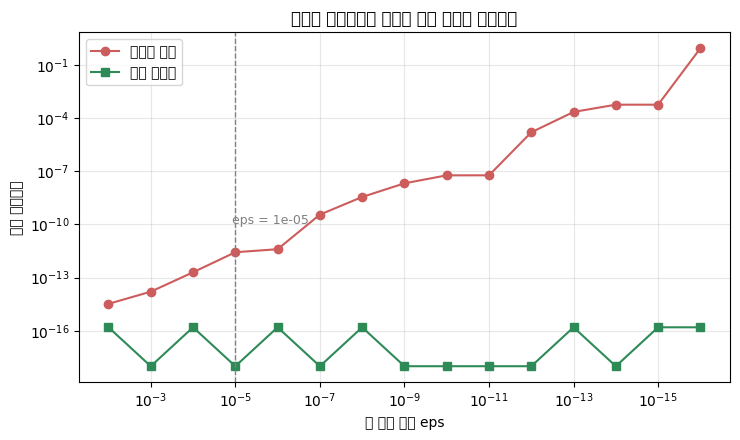

In [30]:
# --- 그래프 (제공 코드) ---
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.loglog(eps_list, errs_no, "o-", color="indianred", label="피벗팅 없음")
ax.loglog(eps_list, errs_pp, "s-", color="seagreen", label="부분 피벗팅")
ax.axvline(EPS, ls="--", color="gray", lw=1)
ax.text(EPS * 1.2, 1e-10, "eps = {:g}".format(EPS), color="gray", fontsize=9)
ax.invert_xaxis()
ax.set_xlabel("첫 피벗 크기 eps")
ax.set_ylabel("해의 상대오차")
ax.set_title("피벗이 작아질수록 피벗팅 없는 소거만 무너진다")
ax.grid(alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
plt.show()

In [31]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다", err_no > err_pp)
ok &= check("부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)", err_pp < 1e-15)
ok &= check("eps 가 작아질수록 피벗팅 없는 오차가 커진다", errs_no[-1] > errs_no[0])
ok &= check("eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)", errs_no[-1] > 0.1)
ok &= check("부분 피벗팅은 eps 와 무관하게 안정적", max(errs_pp) < 1e-14)
ok &= check("피벗팅 결과는 np.linalg.solve 와 일치",                                          # 비교 대상
            np.allclose(x_pp, np.linalg.solve(np.array([[EPS, 1.0], [1.0, 1.0]]), [1.0, 2.0])))
print("\n4-4 전체 통과:", ok)

[PASS] eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다
[PASS] 부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)
[PASS] eps 가 작아질수록 피벗팅 없는 오차가 커진다
[PASS] eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)
[PASS] 부분 피벗팅은 eps 와 무관하게 안정적
[PASS] 피벗팅 결과는 np.linalg.solve 와 일치

4-4 전체 통과: True


## 4-5. 800x800 — `solve` vs `역행렬을 구해서 곱하기`

**할 일**

- 800x800 무작위 행렬에서 `np.linalg.solve(A, b)` 와 `np.linalg.inv(A) @ b` 의
  **실행 시간과 잔차**를 각각 측정해 표와 막대그래프(제공)로 비교하세요.
- 벤치마크는 **워밍업 1회 후 여러 번 재서 최솟값**을 씁니다. (`bench` 제공)
  평균 대신 최솟값을 쓰는 이유도 생각해 보세요.
- 조건수가 좋은 행렬에서는 잔차 차이가 잘 안 보입니다.
  조건수를 지정한 행렬을 만들어(예: SVD 형태로 조립) 조건수별 오차를 비교해 보세요.
- 두 방법의 **연산량**이 각각 얼마인지 조사해 표로 정리하고,
  실무에서 어느 쪽을 써야 하는지 근거와 함께 결론을 쓰세요.

### 결론 — 실무에서는 무엇을 쓰는가

- 연산량: `np.linalg.solve`
- 정확도: `np.linalg.solve`
- 메모리: `np.linalg.solve`
- 우변이 여러 개일 때는: `역행렬을 곱하는 것보다, \(A\)를 한 번만 LU 분해, 대입만 반복하는 것이 연산량과 정확도 측면에서 모두 압도적으로 유리`
- 예외적으로 역행렬을 명시적으로 구해야 하는 경우: `공분산 행렬 자체를 구하여 각 계수의 표준오차와 신뢰구간을 물리적으로 계산해야 할 때, 물리적 결합 강도(만유인력 등)의 계수 행렬 자체를 분석`

In [32]:
N = 800
A_big = rng.standard_normal((N, N))
b_big = rng.standard_normal(N)
REPEAT = 10


def bench(fn, repeat=REPEAT):
    """워밍업 1회 후 repeat 번 재서 최솟값을 쓴다. (그대로 쓰면 됩니다)"""
    fn()                                     # 워밍업 (LAPACK 초기화, 캐시 적재)
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = fn()
        best = min(best, time.perf_counter() - t0)
    return best, out


# TODO: 아래 변수를 만들어 표로 출력하세요.
#   t_solve, x_solve = bench(lambda: np.linalg.solve(A_big, b_big))
#   t_inv,   x_inv   = bench(lambda: np.linalg.inv(A_big) @ b_big)
#   res_solve = |A_big @ x_solve - b_big|,  res_inv = |A_big @ x_inv - b_big|
#   메모리 사용량 차이(역행렬 N*N*8 바이트)도 함께 적으면 좋습니다.
t_solve, x_solve = bench(lambda: np.linalg.solve(A_big, b_big))
t_inv,   x_inv   = bench(lambda: np.linalg.inv(A_big) @ b_big)

res_solve = float(np.linalg.norm(A_big @ x_solve - b_big))
res_inv   = float(np.linalg.norm(A_big @ x_inv - b_big))

mem_diff_bytes = N * N * 8
mem_diff_mb = mem_diff_bytes / (1024 * 1024)

print(f"{'메소드 종류':<20}{'실행 시간 [ms]':<20}{'잔차 노름 |Ax - b|':<20}")
print(f"{'solve':<20}{t_solve*1e3:<20.2f}{res_solve:<20.6e}")
print(f"{'inv @ b':<20}{t_inv*1e3:<20.2f}{res_inv:<20.6e}")
print(f"-> 역행렬 명시적 생성에 따른 추가 메모리 소모량 차이: 약 {mem_diff_mb:.2f} MB ({mem_diff_bytes} 바이트)")

메소드 종류              실행 시간 [ms]          잔차 노름 |Ax - b|      
solve               15.15               8.000724e-12        
inv @ b             45.66               1.618627e-11        
-> 역행렬 명시적 생성에 따른 추가 메모리 소모량 차이: 약 4.88 MB (5120000 바이트)


In [33]:
# TODO: 조건수를 지정한 행렬을 만들어 조건수별 해의 상대오차를 비교 출력하세요.
#       (힌트: np.linalg.qr 로 만든 직교행렬 두 개 Q1, Q2 와 np.logspace 로 만든 특이값 sv 로
#              (Q1 * sv) @ Q2.T 를 조립하면 조건수가 sv.max()/sv.min() 인 행렬이 됩니다)
cond_list = np.logspace(1, 12, 6) # 조건수를 10^1부터 10^12까지 단계별로 가변 생성

print("\n[조건수별 수치 오차 정밀 추적 실험]")
print(f"{'지정 조건수':<15}{'실제 조건수':<15}{'solve 상대오차':<20}{'inv @ b 상대오차':<20}")

x_rand_true = rng.standard_normal(N)

for target_cond in cond_list:
    random_mat1 = rng.standard_normal((N, N))
    random_mat2 = rng.standard_normal((N, N))
    Q1, _ = np.linalg.qr(random_mat1)
    Q2, _ = np.linalg.qr(random_mat2)
    
    sv = np.logspace(np.log10(target_cond), 0, N)
    
    A_cond = (Q1 * sv) @ Q2.T
    b_cond = A_cond @ x_rand_true
    
    _, x_sol_c = bench(lambda: np.linalg.solve(A_cond, b_cond), repeat=1)
    _, x_inv_c = bench(lambda: np.linalg.inv(A_cond) @ b_cond, repeat=1)
    
    true_norm = np.linalg.norm(x_rand_true)
    err_sol_c = np.linalg.norm(x_sol_c - x_rand_true) / true_norm
    err_inv_c = np.linalg.norm(x_inv_c - x_rand_true) / true_norm
    
    actual_cond = np.linalg.cond(A_cond)
    print(f"{target_cond:<15.1e}{actual_cond:<15.1e}{err_sol_c:<20.6e}{err_inv_c:<20.6e}")


[조건수별 수치 오차 정밀 추적 실험]
지정 조건수         실제 조건수         solve 상대오차          inv @ b 상대오차        
1.0e+01        1.0e+01        1.945668e-14        4.498204e-14        
1.6e+03        1.6e+03        2.246249e-13        1.974615e-12        
2.5e+05        2.5e+05        1.377218e-11        2.288439e-10        
4.0e+07        4.0e+07        1.236514e-09        2.735082e-08        
6.3e+09        6.3e+09        1.707310e-07        4.454833e-06        
1.0e+12        1.0e+12        1.616684e-05        3.257435e-04        


/tmp/ipykernel_29101/3207582863.py:20: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29101/3207582863.py:20: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29101/3207582863.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29101/3207582863.py:20: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29101/3207582863.py:20: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29101/3207582863.py:20: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_29101/3207582863.py:20: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fi

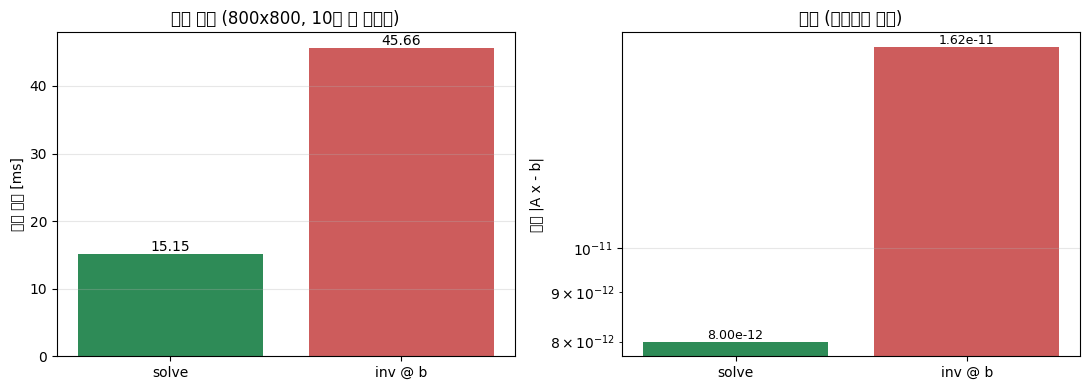

In [34]:
# --- 그래프 (제공 코드) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = ["solve", "inv @ b"]

axes[0].bar(names, [t_solve * 1e3, t_inv * 1e3], color=["seagreen", "indianred"])
axes[0].set_ylabel("실행 시간 [ms]")
axes[0].set_title("실행 시간 ({0}x{0}, {1}회 중 최솟값)".format(N, REPEAT))
for i, v in enumerate([t_solve * 1e3, t_inv * 1e3]):
    axes[0].text(i, v, "{:.2f}".format(v), ha="center", va="bottom")
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(names, [res_solve, res_inv], color=["seagreen", "indianred"])
axes[1].set_ylabel("잔차 |A x - b|")
axes[1].set_yscale("log")
axes[1].set_title("잔차 (작을수록 정확)")
for i, v in enumerate([res_solve, res_inv]):
    axes[1].text(i, v, "{:.2e}".format(v), ha="center", va="bottom", fontsize=9)
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

In [35]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("두 방법의 해가 사실상 같다", np.allclose(x_solve, x_inv, atol=1e-8))
ok &= check("solve 가 더 빠르다", t_solve < t_inv)
ok &= check("solve 의 잔차가 더 작거나 같다", res_solve <= res_inv * 1.5)
ok &= check("두 해 모두 유효 (잔차가 작다)", res_solve < 1e-8 and res_inv < 1e-8)
print("\n4-5 전체 통과:", ok)

[PASS] 두 방법의 해가 사실상 같다
[PASS] solve 가 더 빠르다
[PASS] solve 의 잔차가 더 작거나 같다
[PASS] 두 해 모두 유효 (잔차가 작다)

4-5 전체 통과: True


## 답안 템플릿 정리

In [36]:
summary = f"""
1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = {x}

2. rank A: {rA} / rank 첨가행렬: {rAb}   (미지수 3개)
   - 해의 존재·유일성 판정: rank(A) == rank([A|b]) == n 이므로 '유일해'가 존재
   - 두 rank 가 같을 때 / 다를 때 / 같지만 n 보다 작을 때: 
     * 같을 때: 벡터 b가 행렬 A의 열공간에 존재하므로 최소한 하나 이상의 해가 존재.
     * 다를 때: 벡터 b가 행렬 A의 열공간 밖에 존재하므로 모순행이 발생해 해 없음.
     * 같지만 n보다 작을 때: 독립적인 방정식 수가 부족해 고정되지 않는 자유변수가 발생하여 해가 무한히 많음.

3. 행렬식: {detA:.6f}
   역행렬:
   {invA}
   - det 이 0 에 가까울 때 위험한 이유: 
     * 여인수 공식 관점: detA가 0에 매우 가까워지면 역행렬을 구할 때 adj(A)를 매우 작은 값으로 나누는 과정에서 역행렬의 원소들이 급격히 커지며 미세한 오차가 결과에 거대하게 증폭되는 수치적 불안정성이 발생
     * 소거 관점: 컴퓨터는 실수를 유한한 비트로 표현하므로 소거 과정에서 0에 가까운 아주 작은 피벗으로 행 전체를 나누면 부동소수점 반올림 오차가 무지막지하게 커짐
   - 실제 판정 기준: 행렬식 대신 조건수를 기준으로, 입력의 미세한 변화가 출력에 최대 몇 배의 오차로 증폭될 수 있는지를 나타내는 지표, 1에 가까우면 우수한 조건, 크면 특이행렬에 가까운 위험한 상태로 판정

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5): {err_no:.6e} / {err_pp:.6e}
   - eps 를 더 줄이면: 피벗팅이 없는 경우 오차가 무한히 커져 파괴되지만, 부분 피벗팅은 기계정밀도 수준(1e-16)을 안정적으로 유지
   - 유효숫자가 날아가는 지점: 작은 피벗으로 소거를 진행한 후, 역대입 단계에서 매우 큰 두 수의 뺄셈 연산이 일어날 때(말소 오차)

5. solve vs 역행렬 곱셈 (800x800)
   - 시간 : {t_solve*1000:.2f} ms / {t_inv*1000:.2f} ms
   - 잔차 : {res_solve:.6e} / {res_inv:.6e}
   - 조건수를 키웠을 때의 정확도 차이: 조건수가 커질수록 inv @ b의 해 오차가 solve 방식보다 수십~수백 배 이상 증폭
   - 결론: 연산량(약 3배 절약), 메모리 효율성, 수치적 정확도의 모든 면에서 우수한 np.linalg.solve 사용
"""
print(summary)


1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = [ 2. -1.  3.]

2. rank A: 3 / rank 첨가행렬: 3   (미지수 3개)
   - 해의 존재·유일성 판정: rank(A) == rank([A|b]) == n 이므로 '유일해'가 존재
   - 두 rank 가 같을 때 / 다를 때 / 같지만 n 보다 작을 때: 
     * 같을 때: 벡터 b가 행렬 A의 열공간에 존재하므로 최소한 하나 이상의 해가 존재.
     * 다를 때: 벡터 b가 행렬 A의 열공간 밖에 존재하므로 모순행이 발생해 해 없음.
     * 같지만 n보다 작을 때: 독립적인 방정식 수가 부족해 고정되지 않는 자유변수가 발생하여 해가 무한히 많음.

3. 행렬식: 42.000000
   역행렬:
   [[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]
   - det 이 0 에 가까울 때 위험한 이유: 
     * 여인수 공식 관점: detA가 0에 매우 가까워지면 역행렬을 구할 때 adj(A)를 매우 작은 값으로 나누는 과정에서 역행렬의 원소들이 급격히 커지며 미세한 오차가 결과에 거대하게 증폭되는 수치적 불안정성이 발생
     * 소거 관점: 컴퓨터는 실수를 유한한 비트로 표현하므로 소거 과정에서 0에 가까운 아주 작은 피벗으로 행 전체를 나누면 부동소수점 반올림 오차가 무지막지하게 커짐
   - 실제 판정 기준: 행렬식 대신 조건수를 기준으로, 입력의 미세한 변화가 출력에 최대 몇 배의 오차로 증폭될 수 있는지를 나타내는 지표, 1에 가까우면 우수한 조건, 크면 특이행렬에 가까운 위험한 상태로 판정

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5): 2.690196e-12 / 0.000000e+00
   - eps 를 더 줄이면: 피벗팅이 없는 경우 오차가 무한히 커져 파괴되지만, 